# Model Evaluation


## Setup

Load the trained models and test data for evaluation.

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scikitplot as skplt
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
%matplotlib inline

with open("../model.pkl", "rb") as f:
    model_data = pickle.load(f)

model = model_data["model"]
encoders = model_data["encoders"]
feature_names = model_data["feature_names"]
test_accuracy = model_data["test_accuracy"]
test_auc = model_data["test_auc"]
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

### <b>Objective</b>
- <b><font color='yellow'>Can we accurately predict when our airline customer will churn or will not?</font></b> **--------->** <b><font color='yellow'>can we build a model to do so?</font></b> **----------->** <b><font color='yellow'>what sort of features are we going to have to include in the model?</font></b>


<h5>Whether a customer is satisfied or dissatisfied, can we find the factors/features that push them to be so?</h5>

Update: still no exact answer to the above question....

### Comparison between all models(not including unregularized) in one go!!!!

In [270]:
import matplotlib.pyplot as plt
import scikitplot as skplt
from sklearn.metrics import roc_auc_score

def compare_models(models, X_test, y_test):
    model_names = []
    auc_scores = []

    for i, model in enumerate(models):
        model_name = f"Model {i+1}"
        model_names.append(model_name)

        # Make predictions
        y_pred_prob = model.predict_proba(X_test)[:, 1]

        # Calculate AUC score
        auc = roc_auc_score(y_test, y_pred_prob)
        auc_scores.append(auc)

        # Plot ROC curve
        skplt.metrics.plot_roc(y_test, model.predict_proba(X_test), title=f"ROC Curve - {model_name}")

    # Plot AUC comparison
    plt.figure(figsize=(10, 6))
    plt.bar(model_names, auc_scores)
    plt.xlabel("Model")
    plt.ylabel("AUC Score")
    plt.title("AUC Comparison")
    plt.show()

    # Print AUC scores
    for model_name, auc_score in zip(model_names, auc_scores):
        print(f"{model_name}: AUC = {auc_score}")

In [278]:
# Define the models
models = [
    model_1,
    model_2,
    model_3,
    model_lr,
    model_5,
    model_rf
]

In [277]:
M_unregularized

[LogisticRegression(C=10000000000.0),
 LogisticRegression(C=10000000000.0),
 LogisticRegression(C=10000000000.0),
 LogisticRegression(C=10000000000.0),
 LogisticRegression(C=10000000000.0),
 LogisticRegression(C=10000000000.0),
 LogisticRegression(C=10000000000.0),
 LogisticRegression(C=10000000000.0)]

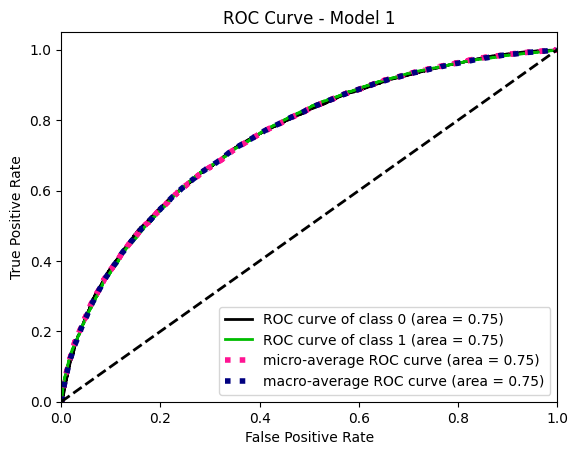

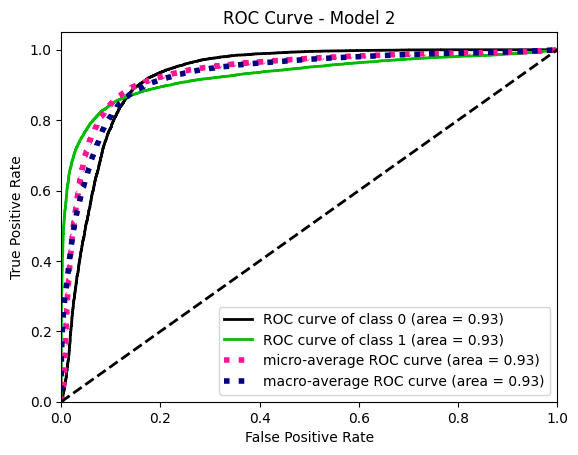

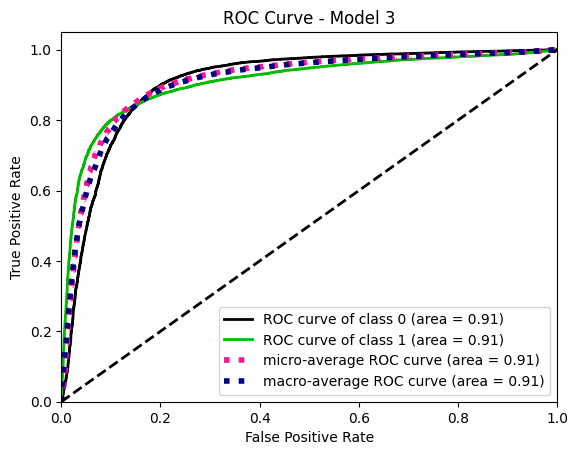

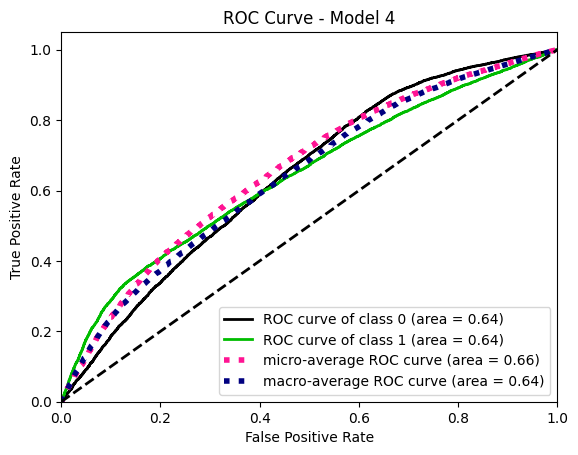

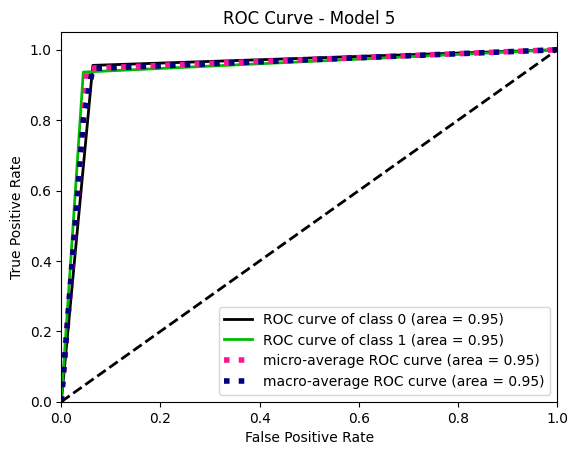

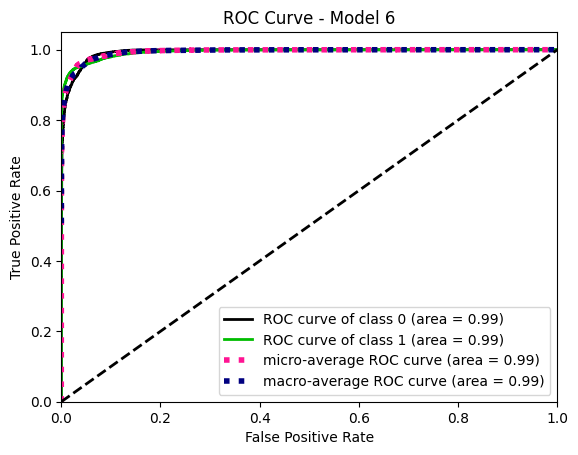

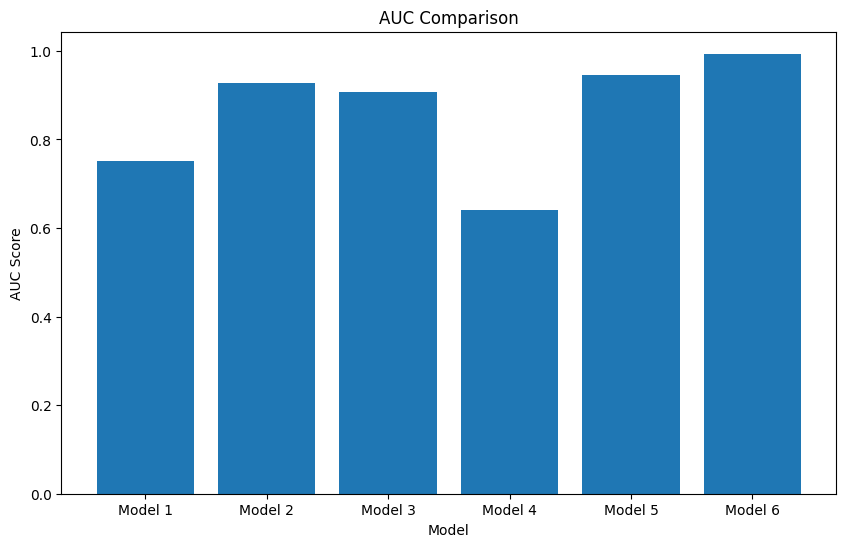

Model 1: AUC = 0.7506861718066697
Model 2: AUC = 0.9267654577702052
Model 3: AUC = 0.9079386048955072
Model 4: AUC = 0.6412692385246368
Model 5: AUC = 0.9459782563100856
Model 6: AUC = 0.9935930212658386


In [279]:
# Call the function to compare models
compare_models(models, X_test, y_test)

## <center>**Conclusion**</center>